In [1]:
import numpy as np
import pandas as pd, os, datetime

import matplotlib.pyplot as plt

# Import the loader function
os.chdir('/g/data/ng72/ms5578/ID_HW_BARRA')
from process_code import load_generation_data

Dask dashboard: /proxy/8787/status


2026-05-28 15:59:04,826 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 3bed0ad80cfb8170b39164e0292167f3 initialized by task ('shuffle-transfer-3bed0ad80cfb8170b39164e0292167f3', 99) executed on worker tcp://127.0.0.1:34765
2026-05-28 15:59:22,237 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 3bed0ad80cfb8170b39164e0292167f3 deactivated due to stimulus 'task-finished-1779947962.223397'


In [2]:
data, info = load_generation_data(
    sdate="2009-07-01",
    edate="2024-06-30",
    mode="daily",
    ftype=["Wind"],
    apply_remove_negatives=False,
    apply_remove_wind_zeros=False,
    apply_min_heatwave_days=False,
    min_heatwave_days_threshold=20,
    apply_clear_agc=False
)

Read gen_details & hw_tseries with Dask: 0.37 sec
Select group: 0.02 sec
--- Starting Dask-Native Process ---


/g/data/ng72/ms5578/ID_HW_BARRA/process_code.py:168: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grp_pd_jittered = grp_pd.groupby(['lat', 'lon'], group_keys=False).apply(


Starting final Dask compute...
Dask compute finished.

--- DASK TIMING REPORT ---
duid_setup: 0.00 seconds
csv_bulk_read: 1.57 seconds
filter_and_clean: 0.02 seconds
type_conversion_and_dropna: 0.10 seconds
date_filter: 0.02 seconds
hw_tseries_filter: 0.04 seconds
aggregate_daily: 0.15 seconds
jitter: 0.97 seconds
final_merge: 0.07 seconds
compute: 40.08 seconds
--- END REPORT ---

Process group: 49.12 sec
Filters: 0.00 sec


In [15]:
def evaluate_duids(df, wind_threshold=40, min_heatwave_days=20):

    all_duids = set(df["DUID"].unique())

    # -------------------
    # WIND (DUID-level impact ONLY for wind rows)
    # -------------------
    wind_df = df[df["fuel_source_primary"] == "Wind"]

    if wind_df.empty:
        wind_keep = all_duids
        wind_fail = set()
    else:
        percent_zeros = (
            wind_df.groupby("DUID")["TOTALMWh"]
            .apply(lambda x: (x == 0).mean() * 100)
        )

        wind_fail = set(percent_zeros[percent_zeros > wind_threshold].index)
        wind_keep = all_duids - wind_fail

    # -------------------
    # HEATWAVE (DUID-level constraint on event coverage only)
    # -------------------
    if "EHF_flag" not in df.columns or df["EHF_flag"].sum() == 0:
        heat_keep = all_duids
        heat_fail = set()
    else:
        hw = df[df["EHF_flag"] == 1].copy()
        hw["date"] = pd.to_datetime(hw["time"]).dt.normalize()

        heat_days = hw.groupby("DUID")["date"].nunique()

        heat_fail = set(heat_days[heat_days < min_heatwave_days].index)
        heat_keep = all_duids - heat_fail

    # -------------------
    # NEGATIVES (ROW-level only, NOT true DUID removal)
    # -------------------
    negative_duids = set(df.loc[df["TOTALMWh"] < 0, "DUID"].unique())

    # IMPORTANT: do NOT treat this as full exclusion in final set
    negative_keep = all_duids  # row filter only

    # -------------------
    # FINAL (only wind + heat affect DUID validity)
    # -------------------
    keep_duids = wind_keep & heat_keep
    drop_duids = all_duids - keep_duids

    return {
        "keep_duids": sorted(keep_duids),
        "drop_duids": sorted(drop_duids),
        "wind_fail": sorted(wind_fail),
        "heat_fail": sorted(heat_fail),
        "negative_duids": sorted(negative_duids),
    }

result = evaluate_duids(data)

print("KEEP:", result["keep_duids"])
print("DROP:", result["drop_duids"])

KEEP: ['ARWF1', 'BALDHWF1', 'BLUFF1', 'BOCORWF1', 'BODWF1', 'BULGANA1', 'CHYTWF1', 'CLEMGPWF', 'CNUNDAWF', 'COOPGWF1', 'CROOKWF2', 'CROWLWF1', 'CRURWF1', 'CTHLWF1', 'DULAWF1', 'FLYCRKWF', 'GRANWF1', 'GULLRWF1', 'GUNNING1', 'HALLWF1', 'HALLWF2', 'HDWF1', 'HDWF2', 'HDWF3', 'KABANWF1', 'KEPWF1', 'KIATAWF1', 'LGAPWF1', 'LGAPWF2', 'LKBONNY1', 'LKBONNY2', 'LKBONNY3', 'MACARTH1', 'MERCER01', 'MEWF1', 'MTGELWF1', 'MUSSELR1', 'MUWAWF1', 'NBHWF1', 'OAKLAND1', 'SALTCRK1', 'SAPHWF1', 'SNOWNTH1', 'SNOWSTH1', 'SNOWTWN1', 'STWF1', 'TARALGA1', 'WATERLWF', 'WGWF1', 'WOODLWN1', 'WPWF', 'WRWF1', 'YENDWF1']
DROP: ['BANGOWF1', 'BANGOWF2', 'BRYB1WF1', 'BRYB2WF2', 'CATHROCK', 'COLWF01', 'DUNDWF1', 'DUNDWF2', 'DUNDWF3', 'ELAINWF1', 'GSWF1A', 'GULLRWF2', 'MOORAWF1', 'MRTLSWF1', 'MTMILLAR', 'MUWAWF2', 'PAREPW1', 'RYEPARK1', 'STARHLWF', 'STOCKYD1']


In [16]:
keep_set = set(result["keep_duids"])
drop_set = set(result["drop_duids"])

info["status"] = info["DUID"].apply(
    lambda x: "keep" if x in keep_set else "drop"
)

In [22]:
len(result["keep_duids"])
len(result["drop_duids"])
len(info["DUID"])

73

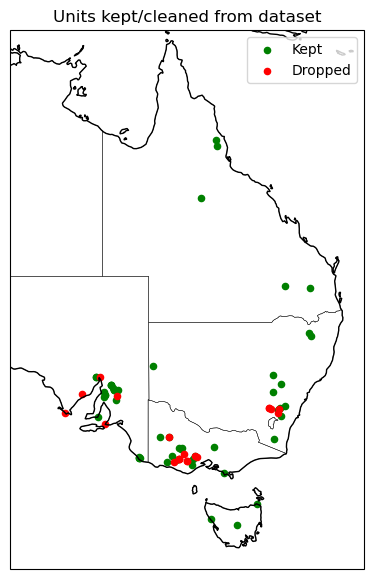

In [27]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Split data
keep = info[info["status"] == "keep"]
drop = info[info["status"] == "drop"]

# Create map
fig = plt.figure(figsize=(7, 7))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.3)  # good for AUS/US-style regional views if available

# Plot points
ax.scatter(
    keep["lon"], keep["lat"],
    color="green", s=20, label="Kept",
    transform=ccrs.PlateCarree()
)

ax.scatter(
    drop["lon"], drop["lat"],
    color="red", s=20, label="Dropped",
    transform=ccrs.PlateCarree()
)

# Optional: focus map extent (adjust if needed)
ax.set_extent([132, 155, -45, -10], crs=ccrs.PlateCarree())

plt.legend()
plt.title("Units kept/cleaned from dataset")
plt.show()